## Module_02 — Data Analysis on Phishing Email Dataset

### Overview
This notebook analyzes the **CEAS_08.csv** phishing email dataset using **Pandas**, **Seaborn**, **Matplotlib**, and **WordCloud**.    
Dataset obtained via *Al-Subaiey, A., Al-Thani, M., Alam, N. A., Antora, K. F., Khandakar, A., & Zaman, S. A. U. (2024, May 19). Novel Interpretable and Robust Web-based AI Platform for Phishing Email Detection. ArXiv.org. https://arxiv.org/abs/2405.11619*

![Description](Assignment_Details.png)


### 1. Import Libraries & Set Theme

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# Seaborn theme
sns.set_theme(style="whitegrid")

### 2. Load Dataset



In [67]:
file_path = "CEAS_08.csv"
df = pd.read_csv(file_path)

df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimension will soon be over!\nBecome a lover no woman will be able to resist!\nhttp://whitedone.com/\n\n\ncome. Even as Nazi tanks were rolling down the stre...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these techniques http://www.brightmade.com\n\n\n,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet.psi.br>,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,">+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug 1, 2008 3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=...",1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/trunk: lib/Mail/SpamAssassin/PerMsgStatus.pm lib/Mail/SpamAssassin/Util/RegistrarBoundaries.pm t/uri_text.t,Would anyone object to removing .so from this list? The .so TLD is \nbasically dead and we've found that lots of bogus domains like lib*.so \nare being caught by this. Also sometimes you'll ha...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-_Hs9yuDwmU5wOteqBO-KnULiisB2QJJIug_bNfnrNH0YoSw/index.html\n\n\n,1,1


### 3. Inspect Dataset

In [68]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (39154, 7)

Columns:
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Data types:
sender        str
receiver      str
date          str
subject       str
body          str
label       int64
urls        int64
dtype: object


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   sender    39154 non-null  str  
 1   receiver  38692 non-null  str  
 2   date      39154 non-null  str  
 3   subject   39126 non-null  str  
 4   body      39154 non-null  str  
 5   label     39154 non-null  int64
 6   urls      39154 non-null  int64
dtypes: int64(2), str(5)
memory usage: 2.1 MB


In [70]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

### 4. Identify Text and Label Columns


In [71]:
text_col = "body"
label_col = "label"

print("Text column:", text_col)
print("Label column:", label_col)

Text column: body
Label column: label


### 5. Clean/Prepare Data

In [72]:
if text_col is None or label_col is None:
    raise ValueError("Could not confidently identify the text and/or label column. Please set text_col and label_col manually in the cell above.")

analysis_df = df[[text_col, label_col]].copy()
analysis_df = analysis_df.dropna(subset=[text_col, label_col])

analysis_df[text_col] = analysis_df[text_col].astype(str).str.strip()
analysis_df = analysis_df[analysis_df[text_col] != ""]

# Convert labels to numeric if possible
analysis_df[label_col] = pd.to_numeric(analysis_df[label_col], errors="coerce")
analysis_df = analysis_df.dropna(subset=[label_col])
analysis_df[label_col] = analysis_df[label_col].astype(int)

# Add text length column
analysis_df["char_length"] = analysis_df[text_col].str.len()
analysis_df["word_count"] = analysis_df[text_col].str.split().str.len()

analysis_df.head()

,body,label,char_length,word_count
0,"Buck up, your troubles caused by small dimension will soon be over!\nBecome a lover no woman will be able to resist!\nhttp://whitedone.com/\n\n\ncome. Even as Nazi tanks were rolling down the stre...",1,273,46
1,Upgrade your sex and pleasures with these techniques http://www.brightmade.com,1,78,9
2,">+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug 1, 2008 3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=...",1,3918,302
3,Would anyone object to removing .so from this list? The .so TLD is \nbasically dead and we've found that lots of bogus domains like lib*.so \nare being caught by this. Also sometimes you'll ha...,0,24415,2660
4,WelcomeFastShippingCustomerSupport\nhttp://7iwfna.blu.livefilestore.com/y1pXdX3kwzhBa8xhXv8tdHbjHn7Tj4VT91YQg5lB5-_Hs9yuDwmU5wOteqBO-KnULiisB2QJJIug_bNfnrNH0YoSw/index.html,1,171,2


In [73]:
print("Cleaned shape:", analysis_df.shape)
print("\nLabel counts:")
print(analysis_df[label_col].value_counts().sort_index())

Cleaned shape: (39154, 4)

Label counts:
label
0    17312
1    21842
Name: count, dtype: int64


### 6. Data Analysis

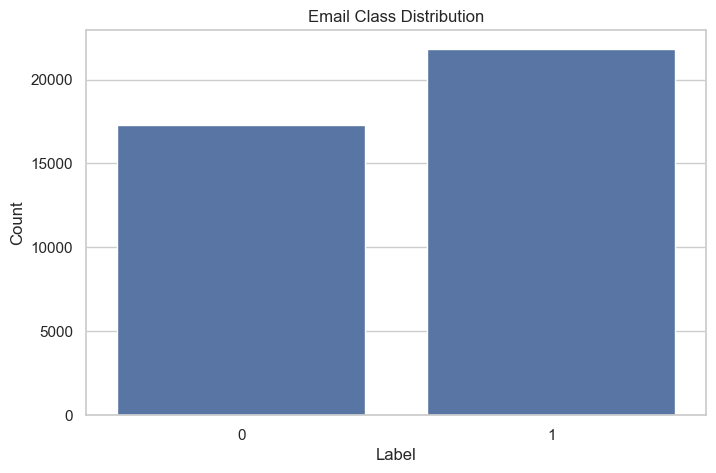

In [74]:
# Class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=analysis_df, x=label_col)
plt.title("Email Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

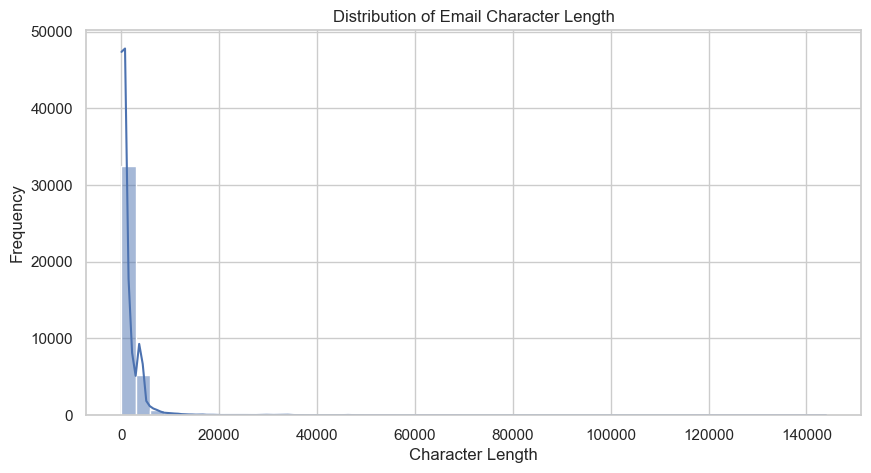

In [75]:
# Character length distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=analysis_df, x="char_length", bins=50, kde=True)
plt.title("Distribution of Email Character Length")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

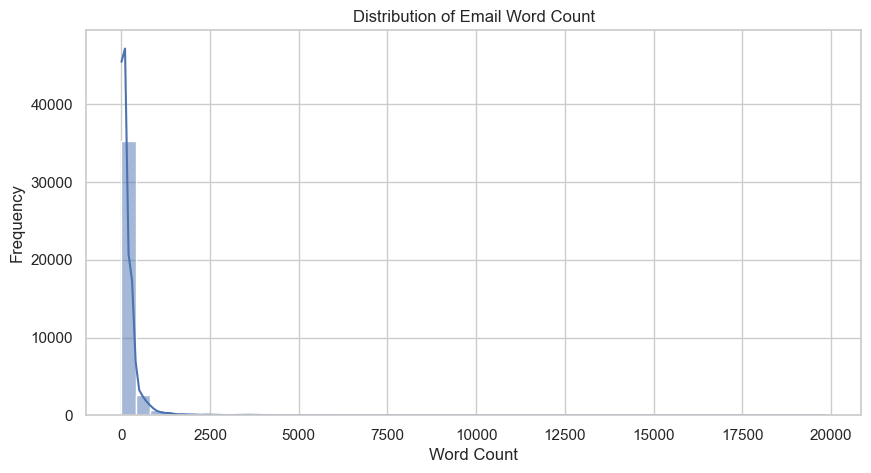

In [76]:
# Word count distribution
plt.figure(figsize=(10, 5))
sns.histplot(data=analysis_df, x="word_count", bins=50, kde=True)
plt.title("Distribution of Email Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

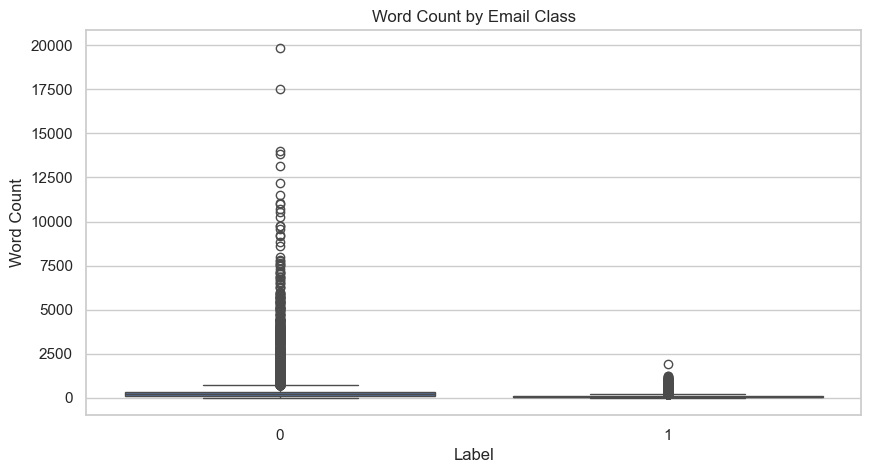

In [77]:
# Compare word counts by class
plt.figure(figsize=(10, 5))
sns.boxplot(data=analysis_df, x=label_col, y="word_count")
plt.title("Word Count by Email Class")
plt.xlabel("Label")
plt.ylabel("Word Count")
plt.show()

### 7. Create Word Clouds


In [78]:
legit_label = 0
phish_label = 1

legit_text = " ".join(analysis_df.loc[analysis_df[label_col] == legit_label, text_col].astype(str))
phish_text = " ".join(analysis_df.loc[analysis_df[label_col] == phish_label, text_col].astype(str))

print("Legitimate text characters:", len(legit_text))
print("Phishing text characters:", len(phish_text))

Legitimate text characters: 43964773
Phishing text characters: 17441072


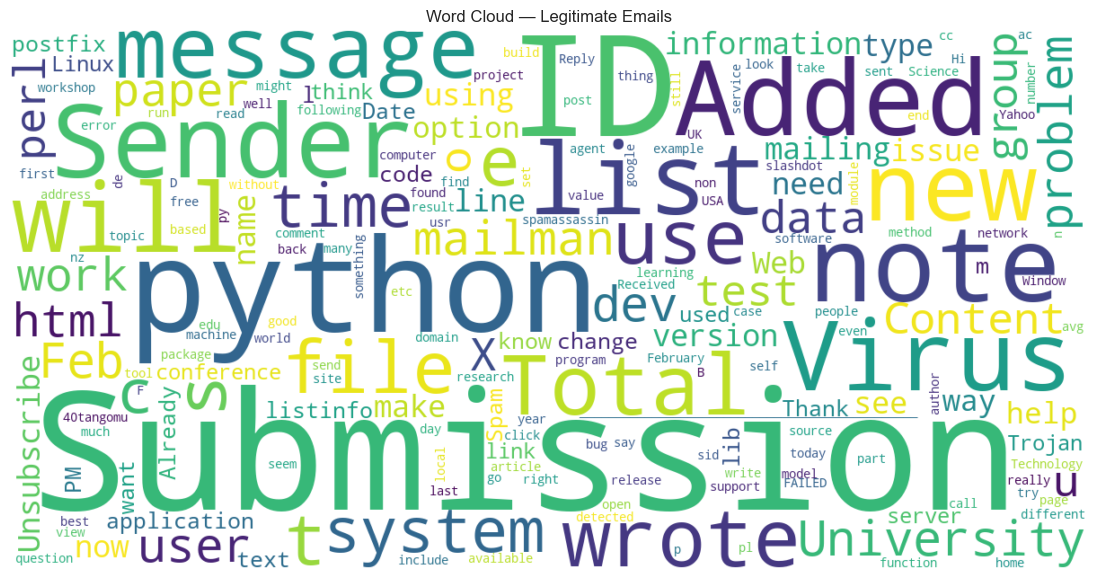

In [79]:
extra_stopwords = {
    "subject", "re", "fw", "fwd", "http", "https", "www", "com", "org", "net",
    "email", "mail", "would", "could", "also", "one", "two", "may", "please"
}
stopwords = STOPWORDS.union(extra_stopwords)

legit_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    collocations=False
).generate(legit_text if legit_text.strip() else "legitimate")

plt.figure(figsize=(14, 7))
plt.imshow(legit_wc, interpolation="bilinear")
plt.title("Word Cloud — Legitimate Emails")
plt.axis("off")
plt.show()

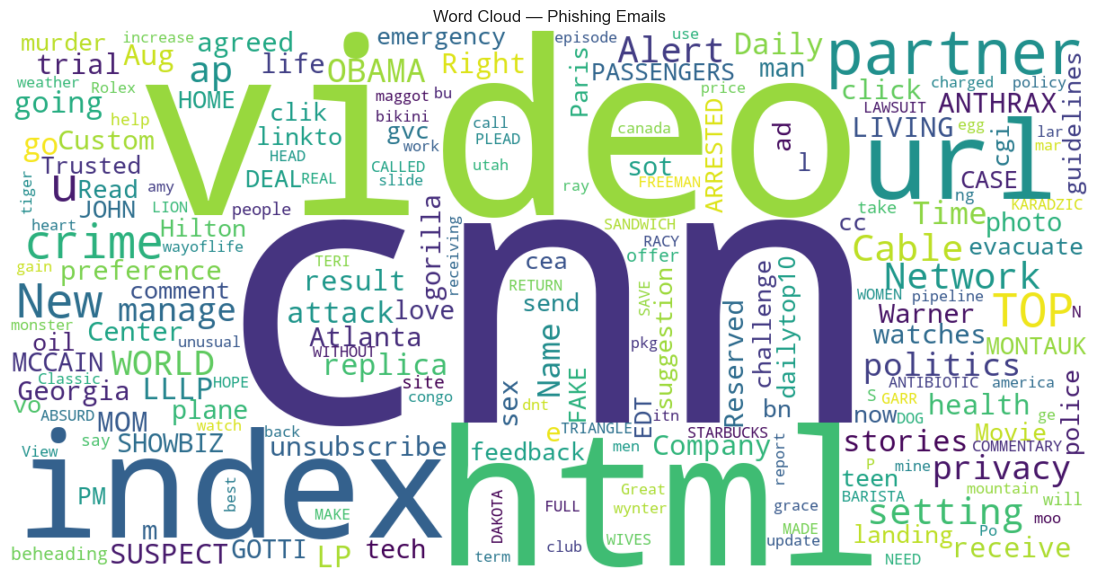

In [80]:
phish_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    collocations=False
).generate(phish_text if phish_text.strip() else "phishing")

plt.figure(figsize=(14, 7))
plt.imshow(phish_wc, interpolation="bilinear")
plt.title("Word Cloud — Phishing Emails")
plt.axis("off")
plt.show()

### 8. Optional: Most Common Words

Frequency view to support word clouds.


In [81]:
from collections import Counter
import re

def most_common_words(text, n=20):
    words = re.findall(r"[A-Za-z']+", text.lower())
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

legit_common = pd.DataFrame(most_common_words(legit_text), columns=["word", "count"])
phish_common = pd.DataFrame(most_common_words(phish_text), columns=["word", "count"])

print("Most common words in legitimate emails:")
display(legit_common)

print("\nMost common words in phishing emails:")
display(phish_common)

Most common words in legitimate emails:


,word,count
0,submission,52417
1,python,33281
2,added,19659
3,sender,19428
4,notes,18405
5,virus,17247
6,will,16972
7,list,15669
8,total,14795
9,wrote,13490



Most common words in phishing emails:


,word,count
0,cnn,109214
1,html,65167
2,video,59832
3,index,59277
4,url,29506
5,partners,29325
6,crime,15596
7,top,15192
8,news,12759
9,network,8718
